# Phase 3 — Model A: MLP (Multi-Layer Perceptron)
## Blood Vessel Blockage Detection Project

**What is MLP?**
- MLP = Multi-Layer Perceptron — sabse basic deep learning model
- Fully connected layers — har neuron doosre se connected hota hai
- Tabular data ke liye BEST deep learning model

**Architecture:**
```
Input (15) → Dense(128) → Dropout → Dense(64) → Dropout → Dense(32) → Dense(1)
```

**Key Concepts:**
- **ReLU Activation** — non-linearity add karta hai
- **Dropout** — overfitting rokta hai
- **Adam Optimizer** — smart learning rate
- **Binary Cross Entropy** — classification loss

In [3]:
from google.colab import files
read = files.upload()

Saving phase2_labeled_data.csv to phase2_labeled_data.csv


In [4]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

print('All libraries imported!')

All libraries imported!


---
## Step 1 — Load Phase 2 Labeled Data

In [5]:
df = pd.read_csv('phase2_labeled_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 19)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency,blockage_score,blockage_label,confidence,risk_level
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0,0.863222,16.366643,158.577612,0.136523,1.394930,0,0,High,Low Risk
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,113.0,0.840300,0.288642,24.0,1.991006,75.379801,94.953946,0.246316,0.574505,12,1,High,Critical Risk
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0,1.650262,45.894002,99.020324,0.245627,0.745173,7,1,Medium,Critical Risk
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0,1.924178,29.407435,164.719245,0.191426,0.740694,4,1,Low,High Risk
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0,1.509978,15.962453,105.235446,0.147986,1.148175,0,0,High,Low Risk


In [6]:
# Separate features and labels
feature_cols = [c for c in df.columns
                if c not in ['blockage_score','blockage_label','confidence','risk_level']]

X = df[feature_cols].values.astype(np.float64)
y = df['blockage_label'].values.astype(np.float64)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Normal patients  :', (y==0).sum())
print('Blockage patients:', (y==1).sum())

X shape: (2000, 15)
y shape: (2000,)
Normal patients  : 1153
Blockage patients: 847


---
## Step 2 — Train / Validation / Test Split

**Why 70 / 15 / 15 split?**
- **Train (70%)** → Model yahan se seekhta hai
- **Validation (15%)** → Training ke dauran check karo — overfitting toh nahi?
- **Test (15%)** → Final unbiased evaluation — model ne kabhi yeh data nahi dekha

**Stratified Split kyu?**
- Normal: 57.7%, Blockage: 42.3%
- Stratified = yahi ratio teeno splits mein maintain hoga

In [7]:
# Scale features first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('Train size :', X_train.shape, '| Blockage%:', round(y_train.mean()*100,1))
print('Val   size :', X_val.shape,   '| Blockage%:', round(y_val.mean()*100,1))
print('Test  size :', X_test.shape,  '| Blockage%:', round(y_test.mean()*100,1))

Train size : (1400, 15) | Blockage%: 42.4
Val   size : (300, 15) | Blockage%: 42.3
Test  size : (300, 15) | Blockage%: 42.3


---
## Step 3 — MLP Architecture

**Layer by Layer explanation:**

```
Input Layer  : 15 neurons  (15 features)
     ↓
Dense(128)   : 128 neurons + ReLU  — complex patterns seekhta hai
Dropout(0.3) : 30% neurons randomly off — overfitting rokta hai
     ↓
Dense(64)    : 64 neurons + ReLU   — features compress karta hai
Dropout(0.2) : 20% neurons randomly off
     ↓
Dense(32)    : 32 neurons + ReLU   — final pattern extraction
     ↓
Dense(1)     : 1 neuron + Sigmoid  — 0 to 1 probability output
```

**Sigmoid output:**
- Output > 0.5 = Blockage
- Output ≤ 0.5 = Normal

In [8]:
# ─────────────────────────────────────────────
# MLP Implementation from Scratch (NumPy)
# ─────────────────────────────────────────────

class MLP:
    """
    Multi-Layer Perceptron for Binary Classification
    Architecture: 15 → 128 → 64 → 32 → 1
    Optimizer   : Adam
    Loss        : Binary Cross Entropy
    Activation  : ReLU (hidden) + Sigmoid (output)
    Regularization: Dropout
    """

    def __init__(self, layer_dims, dropout_rates, lr=0.001):
        """
        layer_dims   : [15, 128, 64, 32, 1]
        dropout_rates: [0.3, 0.2, 0.0]  — per hidden layer
        lr           : learning rate for Adam
        """
        self.dims    = layer_dims
        self.drops   = dropout_rates
        self.lr      = lr
        self.n       = len(layer_dims) - 1  # number of layers
        self.training = True

        # He initialization — best for ReLU networks
        # W = random * sqrt(2/fan_in)  → prevents vanishing gradients
        self.W = []
        self.b = []
        for i in range(self.n):
            fan_in = layer_dims[i]
            W = np.random.randn(fan_in, layer_dims[i+1]) * np.sqrt(2.0 / fan_in)
            b = np.zeros((1, layer_dims[i+1]))
            self.W.append(W)
            self.b.append(b)

        # Adam optimizer states (m=momentum, v=velocity)
        self.mW = [np.zeros_like(w) for w in self.W]
        self.vW = [np.zeros_like(w) for w in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]
        self.vb = [np.zeros_like(b) for b in self.b]
        self.t  = 0  # time step for Adam bias correction

    # ── Activation Functions ──────────────────
    def relu(self, x):        return np.maximum(0, x)
    def relu_grad(self, x):   return (x > 0).astype(np.float64)
    def sigmoid(self, x):     return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    # ── Dropout ──────────────────────────────
    def dropout(self, x, rate):
        """
        Dropout: Training mein random neurons off karo
        rate=0.3 → 30% neurons = 0
        Testing mein dropout OFF hota hai (self.training = False)
        """
        if not self.training or rate == 0:
            return x, np.ones_like(x)
        mask = (np.random.rand(*x.shape) > rate).astype(np.float64)
        # Inverted dropout — scale up to maintain expected value
        return x * mask / (1 - rate), mask / (1 - rate)

    # ── Forward Pass ─────────────────────────
    def forward(self, X):
        """
        Input → Layer1 → Dropout → Layer2 → Dropout → Layer3 → Output
        """
        self.cache = []  # save for backprop
        h = X

        for i in range(self.n):
            z = h @ self.W[i] + self.b[i]  # Linear: z = W*x + b

            if i < self.n - 1:
                a = self.relu(z)                       # ReLU activation
                drop_rate = self.drops[i] if i < len(self.drops) else 0
                a_drop, mask = self.dropout(a, drop_rate)  # Dropout
                self.cache.append((h, z, a, mask))
                h = a_drop
            else:
                a = self.sigmoid(z)                    # Sigmoid for output
                self.cache.append((h, z, a, None))
                h = a

        return h  # Final probability (0 to 1)

    # ── Loss Function ─────────────────────────
    def binary_cross_entropy(self, y_true, y_pred):
        """
        BCE = -(y*log(p) + (1-y)*log(1-p))
        Perfect prediction → loss = 0
        Wrong prediction   → loss = large number
        """
        eps = 1e-9  # avoid log(0)
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # ── Backward Pass (Backpropagation) ───────
    def backward(self, X, y_true, y_pred):
        """
        Backprop: Output se Input ki taraf gradient calculate karo
        Chain rule use karke har layer ka gradient nikalo
        """
        bsz = X.shape[0]
        gW, gb = [], []
        delta = (y_pred - y_true.reshape(-1,1)) / bsz  # Output layer gradient

        for i in reversed(range(self.n)):
            h_prev, z, a, mask = self.cache[i]
            dW = h_prev.T @ delta
            db = delta.sum(axis=0, keepdims=True)
            gW.insert(0, dW)
            gb.insert(0, db)

            if i > 0:
                delta = (delta @ self.W[i].T) * self.relu_grad(self.cache[i-1][1])
                # Apply dropout mask in backward pass too
                if mask is not None:
                    delta = delta * self.cache[i-1][3]

        return gW, gb

    # ── Adam Optimizer ────────────────────────
    def adam_update(self, gW, gb, b1=0.9, b2=0.999, eps=1e-8):
        """
        Adam = Adaptive Moment Estimation
        - m = exponential moving average of gradients (momentum)
        - v = exponential moving average of squared gradients
        - Bias correction for first few steps
        - Each parameter gets its own adaptive learning rate
        """
        self.t += 1
        for i in range(self.n):
            # Weights update
            self.mW[i] = b1 * self.mW[i] + (1-b1) * gW[i]
            self.vW[i] = b2 * self.vW[i] + (1-b2) * gW[i]**2
            mW_hat = self.mW[i] / (1 - b1**self.t)  # Bias correction
            vW_hat = self.vW[i] / (1 - b2**self.t)
            self.W[i] -= self.lr * mW_hat / (np.sqrt(vW_hat) + eps)

            # Bias update
            self.mb[i] = b1 * self.mb[i] + (1-b1) * gb[i]
            self.vb[i] = b2 * self.vb[i] + (1-b2) * gb[i]**2
            mb_hat = self.mb[i] / (1 - b1**self.t)
            vb_hat = self.vb[i] / (1 - b2**self.t)
            self.b[i] -= self.lr * mb_hat / (np.sqrt(vb_hat) + eps)

    # ── Training Loop ─────────────────────────
    def fit(self, X_train, y_train, X_val, y_val, epochs=150, batch_size=32):
        """
        Mini-batch gradient descent:
        1. Data ko batches mein divide karo
        2. Har batch pe forward + backward pass
        3. Adam se weights update
        4. Validation loss track karo (early stopping)
        """
        train_losses, val_losses = [], []
        train_accs,   val_accs   = [], []
        best_val_loss = np.inf
        best_weights  = None
        patience, patience_counter = 15, 0

        for epoch in range(epochs):
            # ── Training Phase ──
            self.training = True
            idx = np.random.permutation(len(X_train))  # Shuffle
            Xs, ys = X_train[idx], y_train[idx]

            batch_losses = []
            for start in range(0, len(X_train), batch_size):
                Xb = Xs[start:start+batch_size]
                yb = ys[start:start+batch_size]

                y_hat = self.forward(Xb)
                loss  = self.binary_cross_entropy(yb, y_hat.flatten())
                gW, gb = self.backward(Xb, yb, y_hat)
                self.adam_update(gW, gb)
                batch_losses.append(loss)

            # ── Validation Phase ──
            self.training = False
            train_pred = self.forward(X_train).flatten()
            val_pred   = self.forward(X_val).flatten()

            t_loss = self.binary_cross_entropy(y_train, train_pred)
            v_loss = self.binary_cross_entropy(y_val, val_pred)
            t_acc  = accuracy_score(y_train, (train_pred > 0.5).astype(int))
            v_acc  = accuracy_score(y_val,   (val_pred   > 0.5).astype(int))

            train_losses.append(t_loss)
            val_losses.append(v_loss)
            train_accs.append(t_acc)
            val_accs.append(v_acc)

            # Early Stopping — val loss improve nahi hua toh rok do
            if v_loss < best_val_loss:
                best_val_loss = v_loss
                best_weights  = [w.copy() for w in self.W] + [b.copy() for b in self.b]
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'  Early stopping at epoch {epoch+1}')
                    break

            if (epoch + 1) % 10 == 0:
                print(f'  Epoch [{epoch+1:3d}/{epochs}] '
                      f'Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | '
                      f'Train Acc: {t_acc*100:.1f}% | Val Acc: {v_acc*100:.1f}%')

        # Restore best weights
        n = self.n
        self.W = best_weights[:n]
        self.b = best_weights[n:]
        print('  Best weights restored!')

        return train_losses, val_losses, train_accs, val_accs

    # ── Prediction ────────────────────────────
    def predict_proba(self, X):
        self.training = False
        return self.forward(X).flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) > threshold).astype(int)


print('MLP class defined!')
print('Architecture: 15 → 128 → 64 → 32 → 1')

MLP class defined!
Architecture: 15 → 128 → 64 → 32 → 1


---
## Step 4 — Train MLP Model

In [9]:
np.random.seed(42)

# Build MLP
# layer_dims   = [input, hidden1, hidden2, hidden3, output]
# dropout_rates = [after_layer1, after_layer2, after_layer3]
mlp = MLP(
    layer_dims   = [15, 128, 64, 32, 1],
    dropout_rates= [0.3, 0.2, 0.0],
    lr=0.001
)

print('Training MLP...')
print('='*70)

train_losses, val_losses, train_accs, val_accs = mlp.fit(
    X_train, y_train,
    X_val,   y_val,
    epochs=150,
    batch_size=32
)

print('='*70)
print('Training Complete!')

Training MLP...
  Epoch [ 10/150] Train Loss: 0.0840 | Val Loss: 0.0968 | Train Acc: 96.3% | Val Acc: 95.7%
  Epoch [ 20/150] Train Loss: 0.0591 | Val Loss: 0.0919 | Train Acc: 97.8% | Val Acc: 95.3%
  Epoch [ 30/150] Train Loss: 0.0447 | Val Loss: 0.0883 | Train Acc: 98.6% | Val Acc: 96.3%
  Epoch [ 40/150] Train Loss: 0.0309 | Val Loss: 0.0964 | Train Acc: 98.9% | Val Acc: 96.7%
  Early stopping at epoch 42
  Best weights restored!
Training Complete!


---
## Step 5 — Training Curves

**What to look for:**
- Train loss aur Val loss dono neeche jaayein → Model sikh raha hai ✅
- Train loss neeche, Val loss upar → Overfitting ⚠️
- Dono zyada upar → Underfitting ⚠️

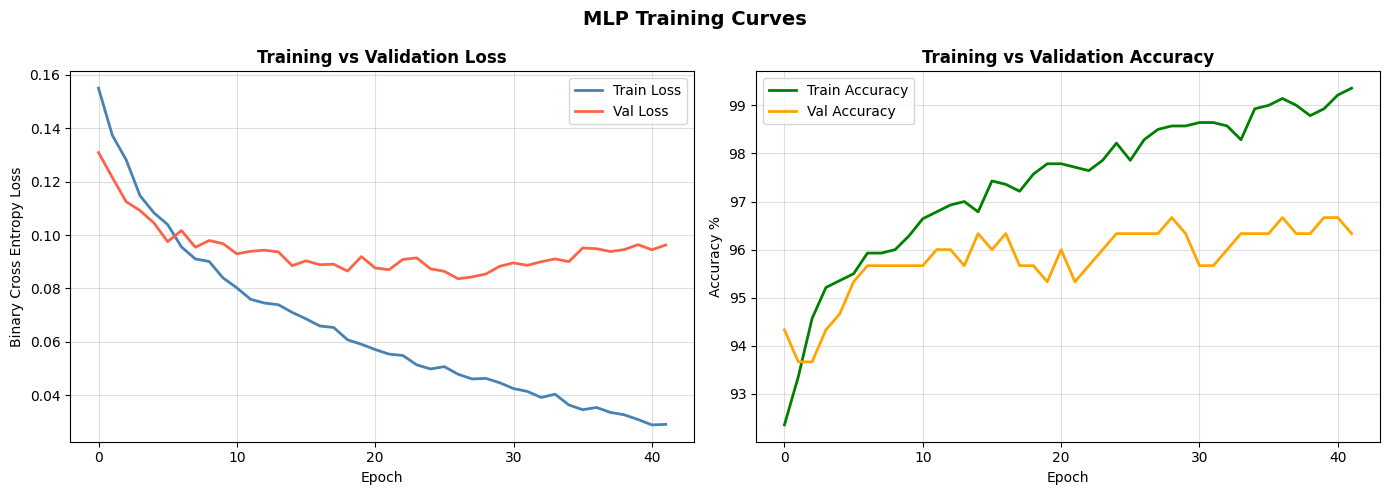

In [10]:
# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=2)
axes[0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross Entropy Loss')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot([a*100 for a in train_accs], label='Train Accuracy', color='green',  linewidth=2)
axes[1].plot([a*100 for a in val_accs],   label='Val Accuracy',   color='orange', linewidth=2)
axes[1].set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.suptitle('MLP Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6 — Test Set Evaluation

In [11]:
# Predict on test set
y_prob = mlp.predict_proba(X_test)
y_pred = mlp.predict(X_test)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('MLP TEST SET RESULTS')
print('='*40)
print(f'Accuracy  : {acc*100:.2f}%')
print(f'Precision : {prec*100:.2f}%')
print(f'Recall    : {rec*100:.2f}%')
print(f'F1-Score  : {f1*100:.2f}%')
print(f'ROC-AUC   : {auc:.4f}')
print('='*40)

MLP TEST SET RESULTS
Accuracy  : 95.67%
Precision : 93.85%
Recall    : 96.06%
F1-Score  : 94.94%
ROC-AUC   : 0.9937


In [12]:
# Classification report
print(classification_report(y_test, y_pred, target_names=['Normal', 'Blockage']))

              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       173
    Blockage       0.94      0.96      0.95       127

    accuracy                           0.96       300
   macro avg       0.95      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



---
## Step 7 — Confusion Matrix

**Reading Confusion Matrix:**
```
                Predicted Normal  |  Predicted Blockage
Actual Normal        TN           |       FP  (False Alarm)
Actual Blockage      FN (Missed!) |       TP
```
- **Medical mein FN (Missed Blockage) most dangerous hai!**
- Isliye Recall important hai — kitne real blockage pakde

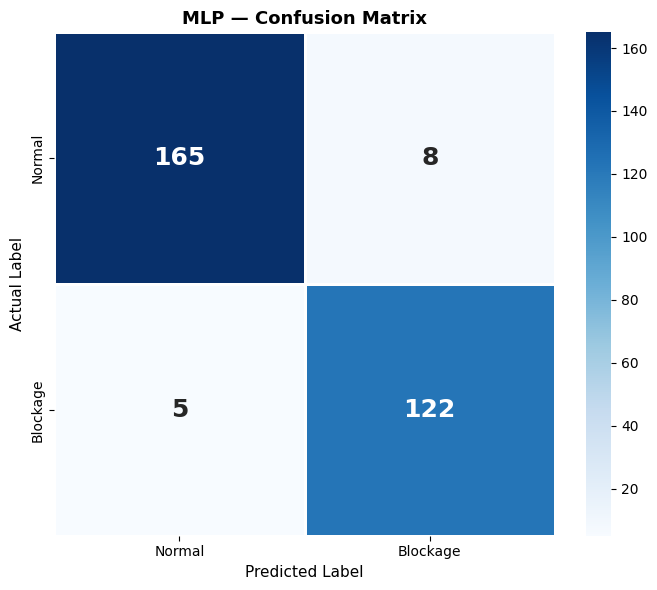

True  Normal   (TN): 165
False Alarm    (FP): 8
Missed Blockage(FN): 5
True  Blockage (TP): 122


In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Blockage'],
            yticklabels=['Normal', 'Blockage'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'})
plt.title('MLP — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Normal   (TN): {tn}')
print(f'False Alarm    (FP): {fp}')
print(f'Missed Blockage(FN): {fn}')
print(f'True  Blockage (TP): {tp}')

---
## Step 8 — ROC Curve

**What is ROC Curve?**
- ROC = Receiver Operating Characteristic
- X-axis = False Positive Rate (Normal patients jo galat flag hue)
- Y-axis = True Positive Rate / Recall (Real blockage jo pakde)
- **AUC (Area Under Curve) closer to 1.0 = better model**
- AUC = 0.5 = Random guessing (useless model)

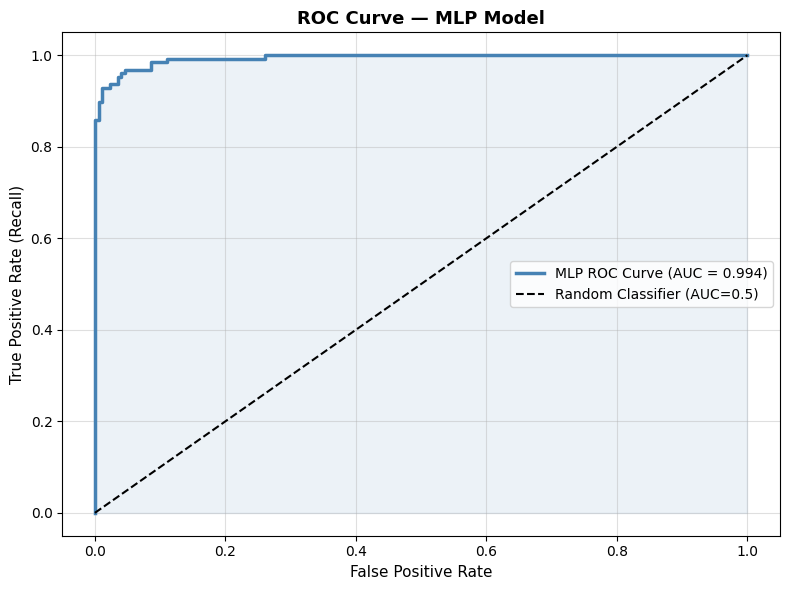

In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'MLP ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC=0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curve — MLP Model', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 9 — Prediction Probability Distribution

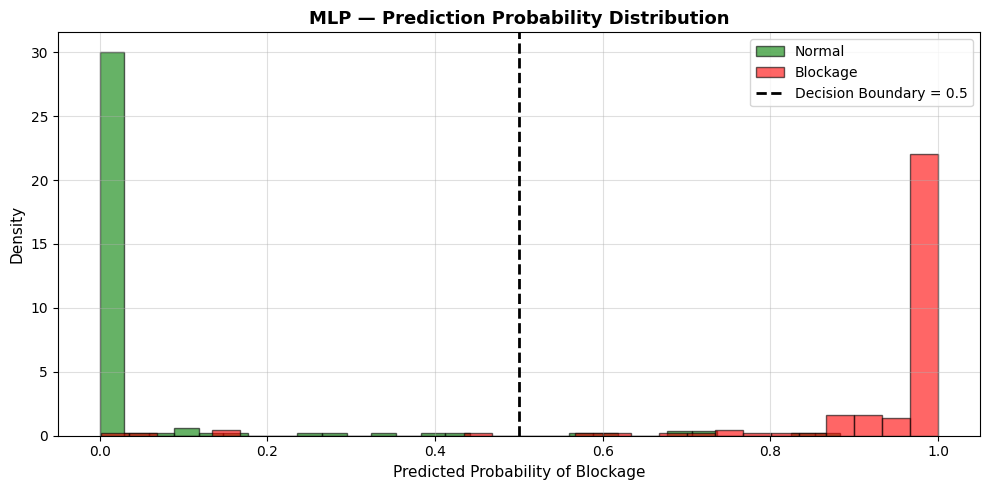

In [15]:
# Probability distribution — Normal vs Blockage
prob_normal   = y_prob[y_test == 0]
prob_blockage = y_prob[y_test == 1]

plt.figure(figsize=(10, 5))
plt.hist(prob_normal,   bins=30, alpha=0.6, color='green', label='Normal',   density=True, edgecolor='black')
plt.hist(prob_blockage, bins=30, alpha=0.6, color='red',   label='Blockage', density=True, edgecolor='black')
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary = 0.5')
plt.xlabel('Predicted Probability of Blockage', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('MLP — Prediction Probability Distribution', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 10 — Performance Metrics Bar Chart

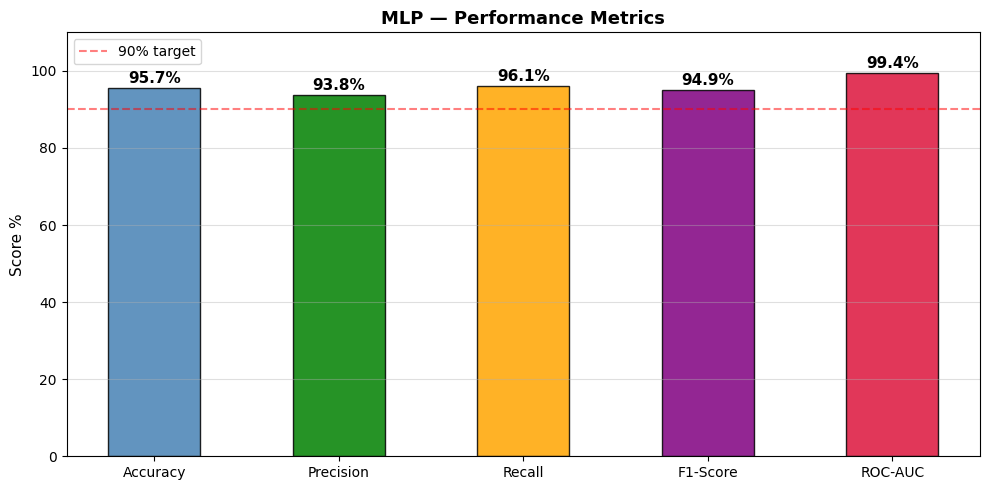

In [16]:
# Metrics visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values  = [acc, prec, rec, f1, auc]
colors  = ['steelblue', 'green', 'orange', 'purple', 'crimson']

plt.figure(figsize=(10, 5))
bars = plt.bar(metrics, [v*100 for v in values], color=colors, edgecolor='black', alpha=0.85, width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 110)
plt.axhline(90, color='red', linestyle='--', alpha=0.5, label='90% target')
plt.ylabel('Score %', fontsize=11)
plt.title('MLP — Performance Metrics', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 11 — K-Fold Cross Validation

**Why K-Fold?**
- Ek baar ka train-test split lucky/unlucky ho sakta hai
- K-Fold = 5 baar alag alag split pe train karo
- Average accuracy = model ki TRUE performance
- Variance = model kitna stable hai

In [17]:
print('Running 5-Fold Cross Validation...')
print('='*55)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accs, fold_f1s, fold_aucs = [], [], []

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
    Xtr, Xvl = X_all[train_idx], X_all[val_idx]
    ytr, yvl = y_all[train_idx], y_all[val_idx]

    # Scale per fold
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xvl = sc.transform(Xvl)

    np.random.seed(42 + fold)
    fold_mlp = MLP([15,128,64,32,1], [0.3,0.2,0.0], lr=0.001)

    # Quick train (50 epochs for CV speed)
    fold_mlp.training = True
    for ep in range(50):
        idx = np.random.permutation(len(Xtr))
        for s in range(0, len(Xtr), 32):
            Xb = Xtr[idx[s:s+32]]
            yb = ytr[idx[s:s+32]]
            yh = fold_mlp.forward(Xb)
            gW, gb = fold_mlp.backward(Xb, yb, yh)
            fold_mlp.adam_update(gW, gb)

    yp    = fold_mlp.predict(Xvl)
    yprob = fold_mlp.predict_proba(Xvl)
    fa    = accuracy_score(yvl, yp)
    ff    = f1_score(yvl, yp)
    fauc  = roc_auc_score(yvl, yprob)

    fold_accs.append(fa)
    fold_f1s.append(ff)
    fold_aucs.append(fauc)
    print(f'  Fold {fold+1} → Accuracy: {fa*100:.1f}% | F1: {ff*100:.1f}% | AUC: {fauc:.3f}')

print('='*55)
print(f'  Mean Accuracy : {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%')
print(f'  Mean F1-Score : {np.mean(fold_f1s)*100:.2f}% ± {np.std(fold_f1s)*100:.2f}%')
print(f'  Mean AUC      : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}')

Running 5-Fold Cross Validation...
  Fold 1 → Accuracy: 94.5% | F1: 93.6% | AUC: 0.993
  Fold 2 → Accuracy: 97.0% | F1: 96.5% | AUC: 0.997
  Fold 3 → Accuracy: 94.5% | F1: 93.5% | AUC: 0.992
  Fold 4 → Accuracy: 97.2% | F1: 96.7% | AUC: 0.997
  Fold 5 → Accuracy: 97.0% | F1: 96.5% | AUC: 0.995
  Mean Accuracy : 96.05% ± 1.27%
  Mean F1-Score : 95.34% ± 1.48%
  Mean AUC      : 0.995 ± 0.002


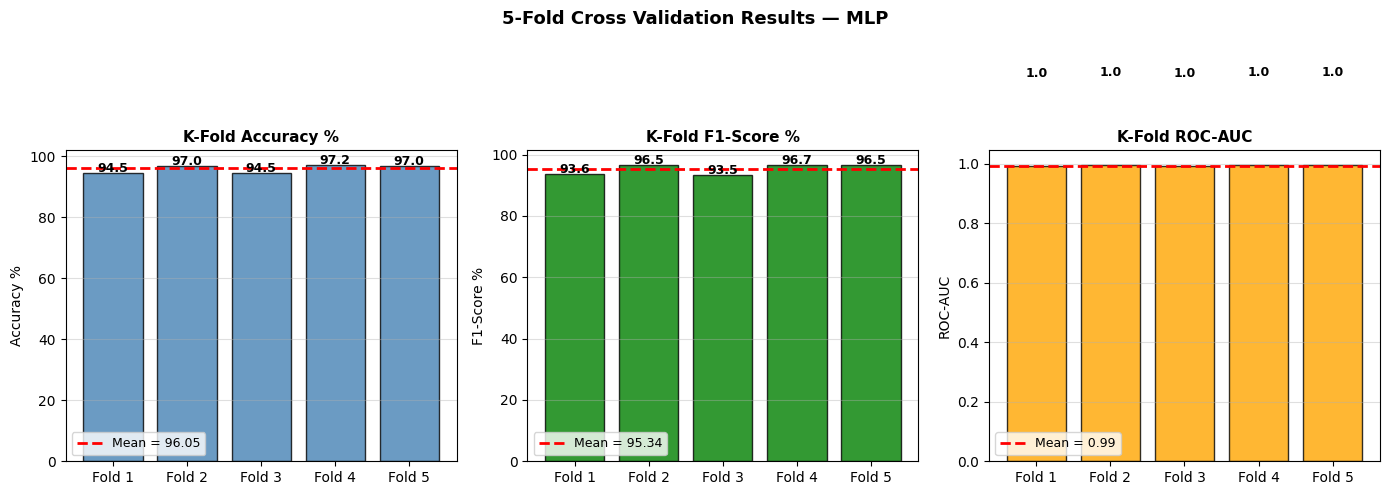

In [18]:
# K-Fold results visualization
folds = [f'Fold {i+1}' for i in range(5)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, vals, name, color in zip(
    axes,
    [[a*100 for a in fold_accs], [a*100 for a in fold_f1s], fold_aucs],
    ['Accuracy %', 'F1-Score %', 'ROC-AUC'],
    ['steelblue', 'green', 'orange']
):
    bars = ax.bar(folds, vals, color=color, edgecolor='black', alpha=0.8)
    ax.axhline(np.mean(vals), color='red', linestyle='--', linewidth=2,
               label=f'Mean = {np.mean(vals):.2f}')
    ax.set_title(f'K-Fold {name}', fontsize=11, fontweight='bold')
    ax.set_ylabel(name)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('5-Fold Cross Validation Results — MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 12 — Sample Patient Predictions

In [19]:
# Show sample predictions
sample_probs = mlp.predict_proba(X_test[:15])
sample_preds = mlp.predict(X_test[:15])
sample_true  = y_test[:15].astype(int)

results = pd.DataFrame({
    'Patient'    : [f'P-{i+1}' for i in range(15)],
    'Probability': [round(p*100, 1) for p in sample_probs],
    'Predicted'  : ['Blockage' if p==1 else 'Normal' for p in sample_preds],
    'Actual'     : ['Blockage' if a==1 else 'Normal' for a in sample_true],
    'Correct?'   : ['✓' if p==a else '✗' for p,a in zip(sample_preds, sample_true)]
})

print('Sample Patient Predictions (first 15):')
results

Sample Patient Predictions (first 15):


,Patient,Probability,Predicted,Actual,Correct?
0,P-1,70.8,Blockage,Blockage,✓
1,P-2,42.6,Normal,Normal,✓
2,P-3,0.0,Normal,Normal,✓
3,P-4,0.0,Normal,Normal,✓
4,P-5,0.1,Normal,Normal,✓
5,P-6,100.0,Blockage,Blockage,✓
6,P-7,99.0,Blockage,Blockage,✓
7,P-8,92.9,Blockage,Blockage,✓
8,P-9,100.0,Blockage,Blockage,✓
9,P-10,100.0,Blockage,Blockage,✓


---
## Step 13 — Save MLP Model

In [21]:
# Save model weights and results
mlp_weights = {'W': mlp.W, 'b': mlp.b}

with open('phase3_mlp_weights.pkl', 'wb') as f:
    pickle.dump(mlp_weights, f)

with open('phase3_mlp_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save results for Phase 6 (Ensemble)
mlp_results = {
    'name'    : 'MLP',
    'accuracy': acc,
    'precision': prec,
    'recall'  : rec,
    'f1'      : f1,
    'auc'     : auc,
    'y_prob_test' : y_prob,
    'y_test'  : y_test
}
with open('phase3_mlp_results.pkl', 'wb') as f:
    pickle.dump(mlp_results, f)

print('Files saved:')
print('  phase3_mlp_weights.pkl   ← Model weights')
print('  phase3_mlp_scaler.pkl    ← Scaler')
print('  phase3_mlp_results.pkl   ← Results for Ensemble (Phase 6)')

Files saved:
  phase3_mlp_weights.pkl   ← Model weights
  phase3_mlp_scaler.pkl    ← Scaler
  phase3_mlp_results.pkl   ← Results for Ensemble (Phase 6)


---
## Phase 3 Summary

In [ ]:
print('========================================')
print('  PHASE 3 — MLP COMPLETE')
print('========================================')
print(f'Architecture : 15 → 128 → 64 → 32 → 1')
print(f'Optimizer    : Adam (lr=0.001)')
print(f'Loss         : Binary Cross Entropy')
print(f'Dropout      : 0.3, 0.2')
print(f'Early Stop   : Yes (patience=15)')
print(f'K-Fold CV    : 5-fold')
print(f'─────────────────────────────────')
print(f'Accuracy     : {acc*100:.2f}%')
print(f'Precision    : {prec*100:.2f}%')
print(f'Recall       : {rec*100:.2f}%')
print(f'F1-Score     : {f1*100:.2f}%')
print(f'ROC-AUC      : {auc:.4f}')
print('========================================')
print('  NEXT → PHASE 4: CNN + Attention')
print('========================================')